# PISA Example Using Public IceCube Data

This analysis is a close variant of what is published in [1], and referred to as *Sample B* in [2] and [3]. The set of systematic uncertainties is slightly reduced and results will be close to, but not identical to the published numbers.

**References:**
* [1] “Measurement of Atmospheric Neutrino Oscillations at 6-56 GeV with IceCube DeepCore,” IceCube Collaboration: M. G. Aartsen et al., Physical Review Letters 120, 071801 (2018). DOI: 10.1103/PhysRevLett.120.071801
* [2] “Measurement of Atmospheric Tau Neutrino Appearance with IceCube DeepCore,” IceCube Collaboration: M. G. Aartsen et al., Phys. Rev. D99.3(2019), p. 032007. DOI: 10.1103/PhysRevD.99.032007
* [3] “Probing the Neutrino Mass Ordering with Atmospheric Neutrinos from Three Years of IceCube DeepCore Data,” IceCube Collaboration: M.G. Aartsen et al., Feb 20, 2019, preprint: arXiv:1902.07771

Dataset must be obtained from https://icecube.wisc.edu/science/data/highstats_nuosc_3y

## Setup

Usually you would need to export the location of the data and the config files to `PISA_RESOURCES`. For this example however, the data is inside our package.

In [1]:
import copy
from uncertainties import unumpy as unp
import matplotlib.pyplot as plt
import pisa
from pisa import ureg
from pisa.analysis.analysis import BasicAnalysis
from pisa.core.distribution_maker import DistributionMaker
from pisa.core.pipeline import Pipeline

<< PISA is running in double precision (FP64) mode; numba is running on CPU (single core) >>


## Model

We can now instantiate the `model` (given our configs) that we later fit to data. This contains two [`Pipeline`](https://icecube.github.io/pisa/pisa.core.html#module-pisa.core.pipeline)s in a [`DistributionMaker`](https://icecube.github.io/pisa/pisa.core.html#module-pisa.core.distribution_maker), one for our neutrinos, and one for the background muons. We turn on profiling so that we will be able to analyse the time it took to generate the model predictions over the course of the analysis.

In [2]:
model = DistributionMaker(
    pipelines=["settings/pipeline/IceCube_3y_neutrinos.cfg", "settings/pipeline/IceCube_3y_muons.cfg"],
    profile=True
)
model

pipeline number,name,detector name,output_binning,output_key,profile
0,neutrinos,,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","('weights', 'errors')",True
1,muons,,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","('weights', 'errors')",True


Our model has a number of free parameters, that will be used in our fit to the data

In [3]:
model.params.free

name,value,nominal_value,range,prior,units,is_fixed
nue_numu_ratio,1,1,"[np.float64(0.5), np.float64(1.5)]",+/- 0.05,dimensionless,False
Barr_uphor_ratio,0,0,"[np.float64(-3.0), np.float64(3.0)]",+/- 1.0,dimensionless,False
Barr_nu_nubar_ratio,0,0,"[np.float64(-3.0), np.float64(3.0)]",+/- 1.0,dimensionless,False
delta_index,0,0,"[np.float64(-0.5), np.float64(0.5)]",+/- 0.1,dimensionless,False
theta13,8.5,8.5,"[np.float64(7.85), np.float64(9.1)]",+/- 0.205,degree,False
theta23,42.3,42.3,"[np.int64(31), np.int64(59)]",uniform,degree,False
deltam31,0.002457,0.002457,"[np.float64(0.001), np.float64(0.007)]",uniform,electron_volt ** 2,False
aeff_scale,1,1,"[np.float64(0.0), np.float64(3.0)]",uniform,dimensionless,False
nutau_norm,1,1,"[np.float64(-1.0), np.float64(8.5)]",uniform,dimensionless,False
nu_nc_norm,1,1,"[np.float64(0.5), np.float64(1.5)]",+/- 0.2,dimensionless,False


The two pipelines are quite different, with most complexity in the neutrino pipeline, that has several [`Stage`](https://icecube.github.io/pisa/pisa.core.html#module-pisa.core.stage)s and free parameters:

In [4]:
model.pipelines[0]

stage number,name,calc_mode,apply_mode,has setup,has compute,has apply,# fixed params,# free params
0,csv_loader,events,events,True,False,True,0,0
1,honda_ip,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",events,True,True,False,1,0
2,barr_simple,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",events,True,True,False,1,4
3,prob3,"""true_allsky_fine"": 200 (true_energy) x 200 (true_coszen)",events,True,True,True,9,3
4,aeff,events,events,False,False,True,2,3
5,hist,events,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,False,True,0,0
6,hypersurfaces,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,True,True,0,5


In [5]:
model.pipelines[0].stages[2].params

name,value,nominal_value,range,prior,units,is_fixed
nu_nubar_ratio,1,1,"[np.float64(0.7), np.float64(1.3)]",+/- 0.1,1,True
nue_numu_ratio,1,1,"[np.float64(0.5), np.float64(1.5)]",+/- 0.05,1,False
Barr_uphor_ratio,0,0,"[np.float64(-3.0), np.float64(3.0)]",+/- 1.0,1,False
Barr_nu_nubar_ratio,0,0,"[np.float64(-3.0), np.float64(3.0)]",+/- 1.0,1,False
delta_index,0,0,"[np.float64(-0.5), np.float64(0.5)]",+/- 0.1,1,False


In contrast, the muon pipeline is rather simple:

In [6]:
model.pipelines[1]

stage number,name,calc_mode,apply_mode,has setup,has compute,has apply,# fixed params,# free params
0,csv_icc_hist,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)","""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,False,True,0,1


## Retrieve Outputs

We can get individual [outputs](https://icecube.github.io/pisa/pisa.core.html#pisa.core.map.MapSet) from a pipeline like so. This fetches outputs from the neutrino pipeline, here 12 maps.

In [7]:
maps = model.pipelines[0].get_outputs()

In [8]:
maps.names

['nue_cc',
 'numu_cc',
 'nutau_cc',
 'nue_nc',
 'numu_nc',
 'nutau_nc',
 'nuebar_cc',
 'numubar_cc',
 'nutaubar_cc',
 'nuebar_nc',
 'numubar_nc',
 'nutaubar_nc']

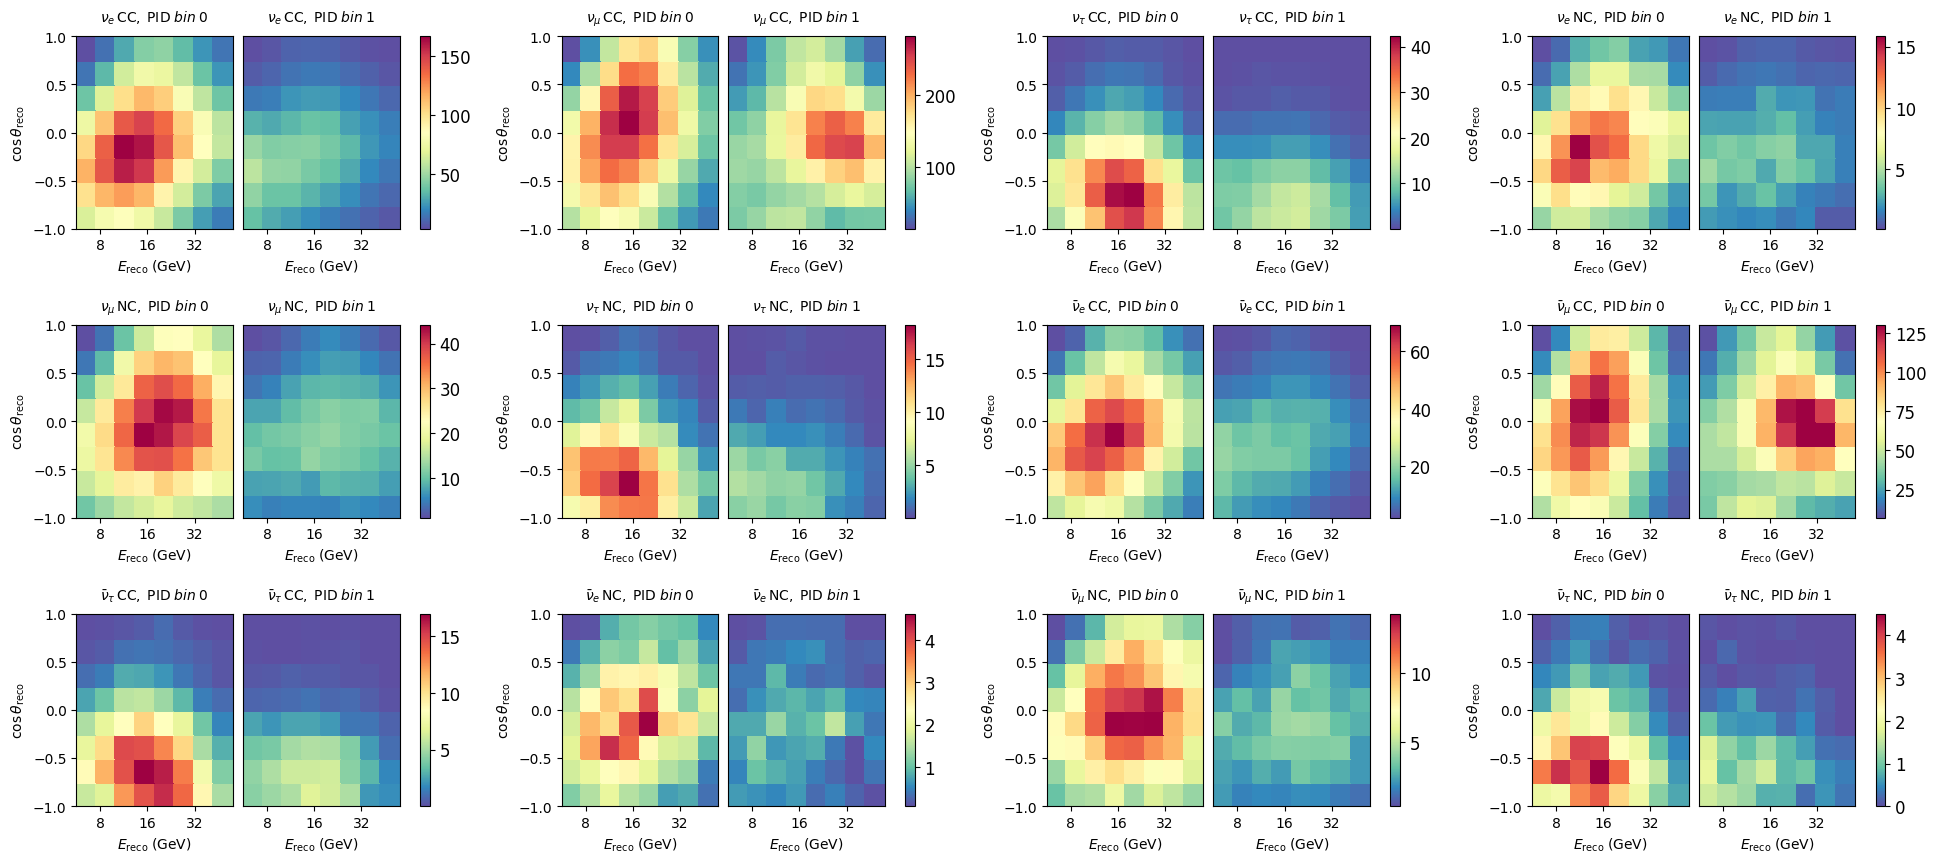

In [9]:
fig, axes = plt.subplots(3,4, figsize=(24,10))
plt.subplots_adjust(hspace=0.5)
axes = axes.flatten()

for m, ax in zip(maps, axes):
    m.plot(ax=ax)

If we are interested in just the total expectation from the full model (all neutrinos + muons), we can do the following:

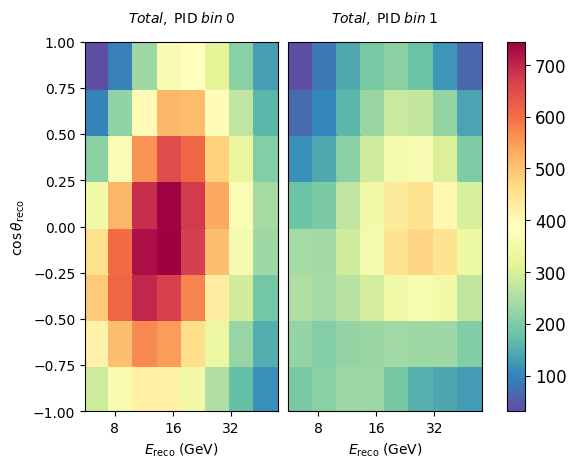

In [10]:
model.get_outputs(return_sum=True).plot()

## Diff plots

Let's explore how a change in one of our nuisance parameters affects the expected counts per bin. Here we choose a *hole ice* parameter and move it a smidge.

In [11]:
# reset all free parameters to put them back to nominal values
model.reset_free()
nominal = model.get_outputs(return_sum=True)

# shift one parameter
model.params.opt_eff_lateral.value = 20
sys = model.get_outputs(return_sum=True)

(<Figure size 640x480 with 3 Axes>,
 <Axes: title={'center': '$Total,{\\;}{\\rm PID}{\\;}bin{\\;}0$'}, xlabel='$E_{\\rm reco} \\; \\left( \\mathrm{GeV} \\right)$', ylabel='$\\cos{\\theta}_{\\rm reco}$'>,
 None)

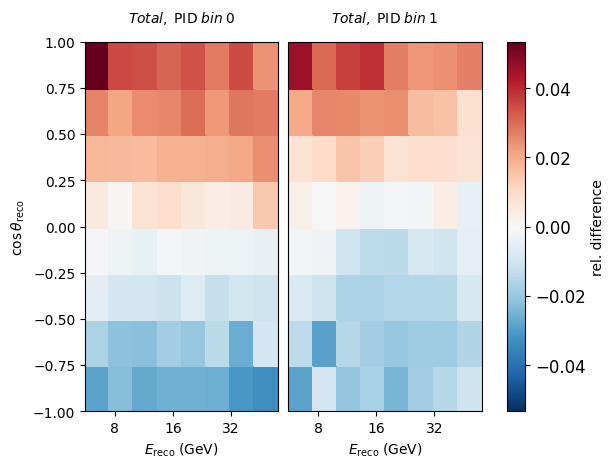

In [12]:
((nominal[0] - sys[0])/nominal[0]).plot(symm=True, clabel="rel. difference")

## Get Data

We can load the real observed data too. This is a Pipeline with no free parameters, as the data is of course fixed.
NB: When developing a new analysis you will **not** be allowed to look at the data as we do here before the box opening (c.f. *blindness*).

In [13]:
# real data
data_maker = Pipeline("settings/pipeline/IceCube_3y_data.cfg")
data = data_maker.get_outputs()

In [14]:
data_maker

stage number,name,calc_mode,apply_mode,has setup,has compute,has apply,# fixed params,# free params
0,csv_data_hist,events,"""dragon_datarelease"": 8 (reco_energy) x 8 (reco_coszen) x 2 (pid)",True,False,False,0,0


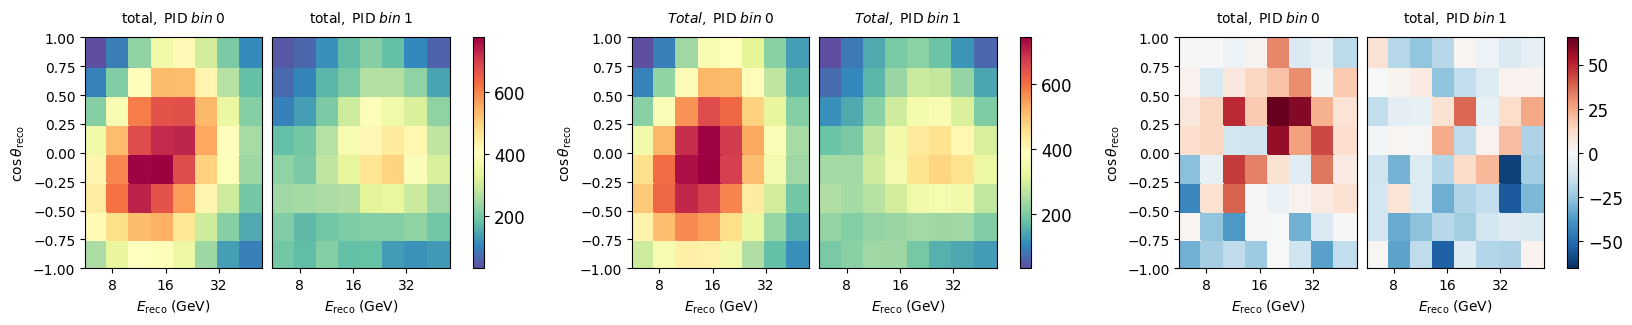

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(20, 3))

model.reset_free()
nominal = model.get_outputs(return_sum=True)

data.plot(ax=ax[0], title="Data")
nominal.plot(ax=ax[1], title="Model")
(data - nominal).plot(ax=ax[2], symm=True, title="Diff")

## Fitting

For fitting we need to configure a minimizer: several standard cfgs are available, but you can also define your own. Here we make use of [SciPy's SLSQP solver](https://docs.scipy.org/doc/scipy/reference/optimize.minimize-slsqp.html).
In addition, we need to choose a ["metric"](https://icecube.github.io/pisa/pisa.utils.html#module-pisa.utils.stats) (objective function), here PISA's ["modified chi-square"](https://icecube.github.io/pisa/pisa.utils.html#pisa.utils.stats.mod_chi2). Also, we fit theta23 octants, which are quasi degenerate, separately. PISA automatically minimizes over the separate outcomes to arrive at a global best fit.

In [16]:
minimizer_cfg = pisa.utils.fileio.from_file('settings/minimizer/slsqp_ftol1e-6_eps1e-4_maxiter1000.json')
# instantiate the analysis object 
ana = BasicAnalysis()

method = "octants"
method_kwargs = {
    "angle": "theta23",
    "inflection_point": 45 * ureg.deg
}
local_fit_kwargs = {
    "method": "scipy",
    "method_kwargs": minimizer_cfg,
    "local_fit_kwargs": None
}

In [ ]:
%%time
result = ana.fit_recursively(
    data_dist=data,
    hypo_maker=model,
    metric='mod_chi2',
    external_priors_penalty=None,
    method=method,
    method_kwargs=method_kwargs,
    local_fit_kwargs=local_fit_kwargs
)

Now we can investigate the [fit result](https://icecube.github.io/pisa/pisa.analysis.html#pisa.analysis.analysis.HypoFitResult), such as the parameter values that have been found to minimize the metric, or the value of the latter itself at this point.

In [18]:
min_metric = result.metric_val
print(f"minimal metric value: {min_metric:.5g}")

minimal metric value: 115.81


In [19]:
bestfit_params = result.params.free
bestfit_params

name,value,nominal_value,range,prior,units,is_fixed
nue_numu_ratio,1.03301,1,"[np.float64(0.5), np.float64(1.5)]",+/- 0.05,dimensionless,False
Barr_uphor_ratio,-0.315637,0,"[np.float64(-3.0), np.float64(3.0)]",+/- 1.0,dimensionless,False
Barr_nu_nubar_ratio,-0.0208958,0,"[np.float64(-3.0), np.float64(3.0)]",+/- 1.0,dimensionless,False
delta_index,-0.0106002,0,"[np.float64(-0.5), np.float64(0.5)]",+/- 0.1,dimensionless,False
theta13,8.51035,8.5,"[np.float64(7.85), np.float64(9.1)]",+/- 0.205,degree,False
theta23,46.251,47.7,"[np.int64(31), np.int64(59)]",uniform,degree,False
deltam31,0.00242612,0.002457,"[np.float64(0.001), np.float64(0.007)]",uniform,electron_volt ** 2,False
aeff_scale,0.934906,1,"[np.float64(0.0), np.float64(3.0)]",uniform,dimensionless,False
nutau_norm,0.610797,1,"[np.float64(-1.0), np.float64(8.5)]",uniform,dimensionless,False
nu_nc_norm,1.26362,1,"[np.float64(0.5), np.float64(1.5)]",+/- 0.2,dimensionless,False


In [20]:
# update the model with the best fit
model.update_params(copy.deepcopy(bestfit_params))

Let's see how good that fit looks. We here construct signed mod_chi2 maps by hand.
You can see that after the fit, it improved considerably, and the distribution of chi2 values is now more uniform - only few features remain visible.

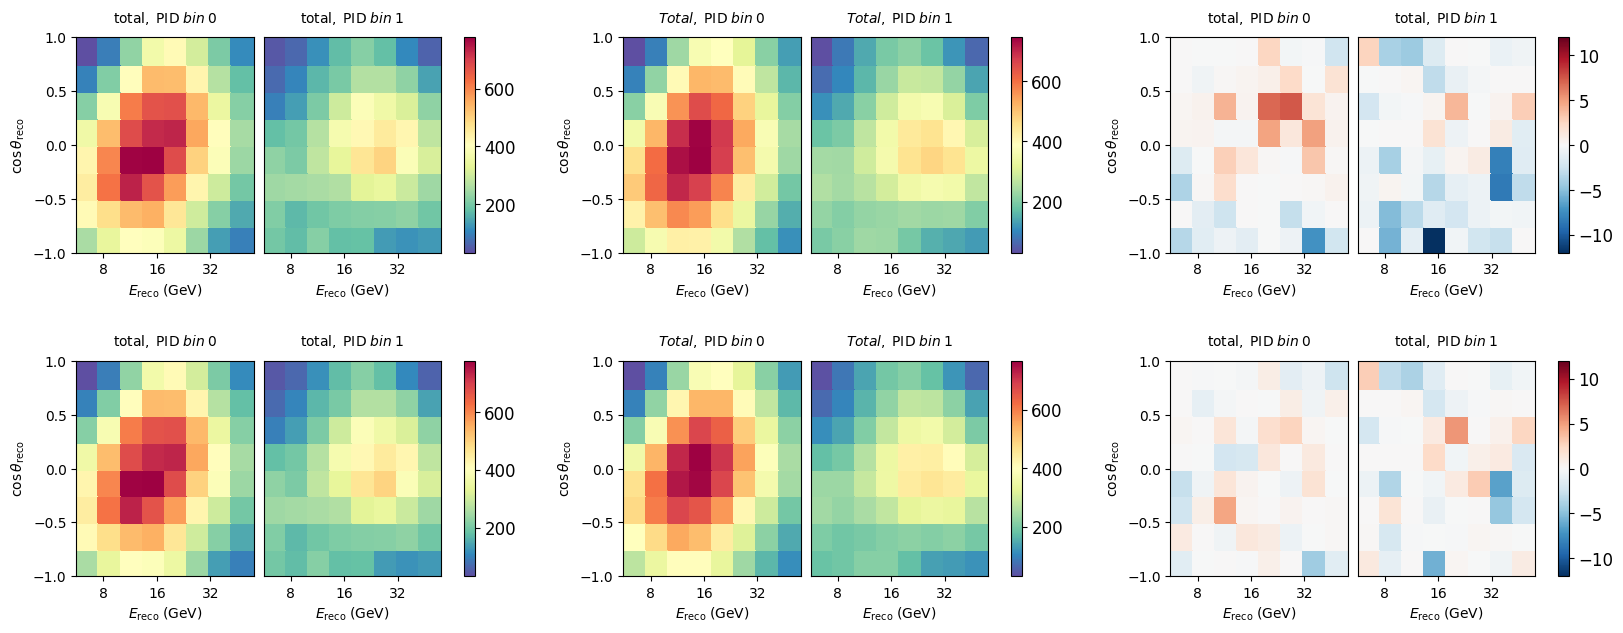

In [21]:
fig, ax = plt.subplots(2, 3, figsize=(20, 7))
plt.subplots_adjust(hspace=0.5)

bestfit = model.get_outputs(return_sum=True)

data.plot(ax=ax[0,0], title="Data")
nominal.plot(ax=ax[0,1], title="Nominal")
diff = data - nominal
(abs(diff)*diff/(nominal + unp.std_devs(nominal.hist['total']))).plot(ax=ax[0,2], symm=True, title=r"signed $\chi^2$", vmin=-12, vmax=12)

data.plot(ax=ax[1,0], title="Data")
bestfit.plot(ax=ax[1,1], title="Bestfit")
diff = data - bestfit
(abs(diff)*diff/(bestfit + unp.std_devs(bestfit.hist['total']))).plot(ax=ax[1,2], symm=True, title=r"signed $\chi^2$", vmin=-12, vmax=12)

When checking the chi2 value from the fitted model, you maybe see that it is around 113, while in the minimizer loop we saw it converged to 116. It is important to keep in mind that in the fit we had extended the metric with prior penalty terms. When we add those back we get the identical number as reported in the fit.

In [22]:
print(data.metric_total(nominal, 'mod_chi2'))
print(data.metric_total(bestfit, 'mod_chi2'))

175.08610766919114
113.03289312869633


Evaluating other metrics just for fun:

In [29]:
for metric in pisa.utils.stats.ALL_METRICS:
    try:
        print(f'{metric} = {data.metric_total(bestfit, metric):.3f}')
    except:
        print(f'{metric} failed')

llh = -64.971
conv_llh = -57.324
barlow_llh failed
mcllh_mean = -541.331
mcllh_eff = -541.484
generalized_poisson_llh failed
chi2 = 128.473
mod_chi2 = 113.033
correct_chi2 = 847.217
weighted_chi2 failed
signed_sqrt_mod_chi2 = -9.176


Adding prior penalty terms

In [24]:
model.update_params(copy.deepcopy(bestfit_params))
print(data.metric_total(bestfit, 'mod_chi2') + model.params.priors_penalty('mod_chi2'))

115.80889047543769


In [25]:
print(result.metric_val)

115.80889047543769


## Storing the results to a file

Since the fit took a while, it might be useful to store the results to a file. (NB: in this example we use a temporary file, but in practice you would just use a real path instead.)

In [26]:
import tempfile
temp = tempfile.NamedTemporaryFile(suffix='.json')
pisa.utils.fileio.to_file(result, temp.name, warn=False)

To reload, we can read the file and re-instantiate the [set of fit parameters](https://icecube.github.io/pisa/pisa.core.html#pisa.core.param.ParamSet).

In [27]:
result_reload = pisa.utils.fileio.from_file(temp.name)
temp.close() # remove the temporary file again
bestfit_params = pisa.core.ParamSet(result_reload['params']).free
bestfit_params

name,value,nominal_value,range,prior,units,is_fixed
nue_numu_ratio,1.03301,1,"[0.5, 1.5]",+/- 0.05,dimensionless,False
Barr_uphor_ratio,-0.315637,0,"[-3.0, 3.0]",+/- 1.0,dimensionless,False
Barr_nu_nubar_ratio,-0.0208958,0,"[-3.0, 3.0]",+/- 1.0,dimensionless,False
delta_index,-0.0106002,0,"[-0.5, 0.5]",+/- 0.1,dimensionless,False
theta13,8.51035,8.5,"[7.85, 9.1]",+/- 0.205,degree,False
theta23,46.251,47.7,"[31, 59]",uniform,degree,False
deltam31,0.00242612,0.002457,"[0.001, 0.007]",uniform,electron_volt ** 2,False
aeff_scale,0.934906,1,"[0.0, 3.0]",uniform,dimensionless,False
nutau_norm,0.610797,1,"[-1.0, 8.5]",uniform,dimensionless,False
nu_nc_norm,1.26362,1,"[0.5, 1.5]",+/- 0.2,dimensionless,False


## Profiling

To understand what parts of the model were executed how many times, and how long it took, the profiling  can help:

In [28]:
model.report_profile()

Pipeline: neutrinos
- setup:        Total time (s): 4.662, n calls: 1
- run:          Total time (s): 410.261, n calls: 782, time/call (s): mean 0.525, max. 24.954, min. 0.040
- get_outputs:  Total time (s): 413.123, n calls: 782, time/call (s): mean 0.528, max. 24.962, min. 0.043
Individual services:
data csv_loader
- setup:    Total time (s): 4.531, n calls: 1
- compute:  Total time (s): +0.000, n calls: 1
- apply:    Total time (s): 0.905, n calls: 782, time/call (s): mean 0.001, max. 0.007, min. +0.000
flux honda_ip
- setup:    Total time (s): 0.025, n calls: 1
- compute:  Total time (s): 23.341, n calls: 1
- apply:    Total time (s): +0.000, n calls: 782, time/call (s): mean +0.000, max. +0.000, min. +0.000
flux barr_simple
- setup:    Total time (s): +0.000, n calls: 1
- compute:  Total time (s): 82.179, n calls: 331, time/call (s): mean 0.248, max. 0.516, min. 0.187
- apply:    Total time (s): +0.000, n calls: 782, time/call (s): mean +0.000, max. +0.000, min. +0.000
osc prob3
-

Here we can see that computing the outputs of the neutrino pipeline on average took approximately half a second.

Apart from the onetime calculation of the atmospheric neutrino fluxes by the ["honda_ip"](https://icecube.github.io/pisa/pisa.stages.flux.html#pisa.stages.flux.honda_ip.honda_ip) service and the loading of the MC events by the ["csv_loader"](https://icecube.github.io/pisa/pisa.stages.data.html#pisa.stages.data.csv_loader.csv_loader) service, the most time-consuming, recurring, operations occur in the ["prob3"](https://icecube.github.io/pisa/pisa.stages.osc.html#pisa.stages.osc.prob3.prob3) neutrino oscillation service and the ["barr_simple"](https://icecube.github.io/pisa/pisa.stages.flux.html#pisa.stages.flux.barr_simple.barr_simple) neutrino flux service.

In contrast, computing the outputs of the muon pipeline took at most $5\times 10^{-3}$ seconds.